## Visualizing the 2D Gaussian Field

This notebook visualizes a 2D r-theta plane Gaussian field generated by a function similar to the `GAUS` subroutine in `mod_layout.f90`. 
The Fortran function calculates the field value as:
```fortran
R2 = ((X-XC)**2.+(Y-YC)**2.)/R0**2.
GAUS = GAUSDATA%Q /R0**2.*EXP(-GAUSDATA%B*R2)
```

### Define Parameters and the Gaussian Function

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_gaussian(x, y, z, params):
    """
    Calculates the sinusoidally perturbed Gaussian field value.
    
    Args:
        x (float or np.ndarray): Cartesian x-coordinate(s).
        y (float or np.ndarray): Cartesian y-coordinate(s).
        z (float): Axial z-coordinate.
        params (dict): Dictionary of Gaussian parameters.
    
    Returns:
        float or np.ndarray: The value of the Gaussian field.
    """
    ak1 = 2 * np.pi * params['K'] / params['ZLEN']
    rk = 2 * np.pi * params['RK'] / params['ZLEN']
    dp = np.pi / 180.0 * params['DP']
    rp = np.pi / 180.0 * params['RP']

    # Calculate perturbed center and core size
    xc = params['XC'] + params['DX'] * np.sin(ak1 * z - dp)
    yc = params['YC'] + params['DY'] * np.sin(ak1 * z - dp)
    r0 = params['R'] + params['DR'] * np.sin(rk * z - rp)
    
    # Avoid division by zero if r0 is ever zero
    if r0 == 0:
        r0 = 1e-16

    # Calculate the squared, normalized distance from the center
    r_squared_normalized = ((x - xc)**2 + (y - yc)**2) / r0**2
    
    # Calculate the Gaussian value
    gaus_value = (params['Q'] / r0**2) * np.exp(-params['B'] * r_squared_normalized)
    
    return gaus_value

In [7]:
# Parameters analogous to GAUSDATA in Fortran
gaus_params = {
    'Q': 1.0,      # Amplitude of the vortex
    'B': 1.0,      # Controls the sharpness of the Gaussian decay
    'R': 1.0,      # Base core size of the vortex
    'XC': 0.0,     # X-coordinate of the center
    'YC': 0.0,     # Y-coordinate of the center
    # Parameters for 3D sinusoidal perturbations (set to 0 for this 2D plot)
    'K': 1.0,      # Axial wavenumber of perturbation
    'RK': 0.0,     # Axial wavenumber for core size perturbation
    'DX': 0.0,     # Amplitude of center perturbation in x
    'DY': 0.0,     # Amplitude of center perturbation in y
    'DR': 0.0,     # Amplitude of core size perturbation
    'DP': 0.0,     # Phase of center perturbation
    'RP': 0.0,     # Phase of core size perturbation
    'ZLEN': 2 * np.pi # Axial domain length
}

# Define the grid in polar coordinates
radius = np.linspace(0, 5, 200)
theta = np.linspace(0, 2 * np.pi, 200)
R, TH = np.meshgrid(radius, theta)
X = R * np.cos(TH)
Y = R * np.sin(TH)
z_slice = 0.0 # assume z = 0

### Test: original

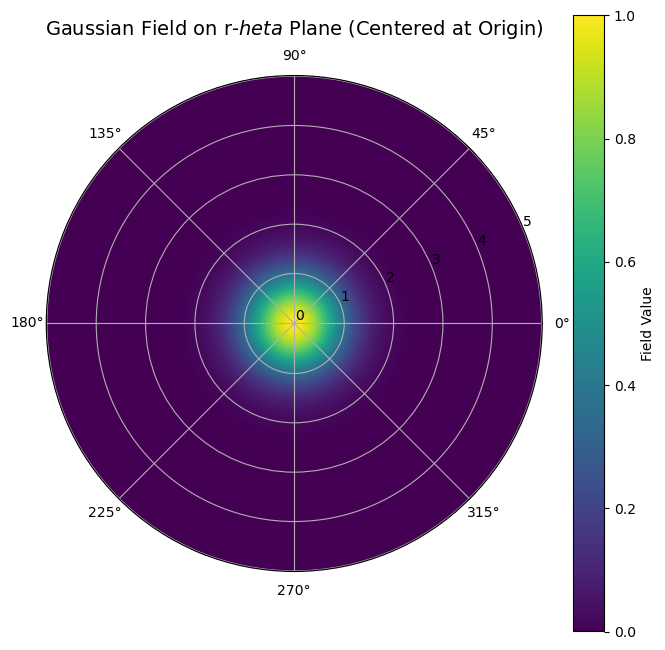

In [8]:
field_values = calculate_gaussian(X, Y, z_slice, gaus_params)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
c = ax.pcolormesh(TH, R, field_values, shading='auto', cmap='viridis')
fig.colorbar(c, ax=ax, label='Field Value')
ax.set_title('Gaussian Field on r-$\theta$ Plane (Centered at Origin)', va='bottom', fontsize=14)
plt.show()

### Test: off-center

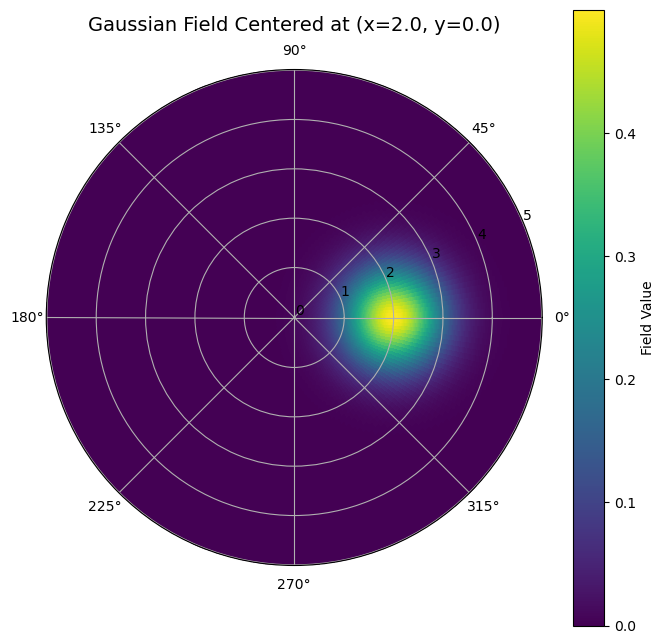

In [9]:
# Update parameters for an off-center Gaussian
gaus_params_offcenter = gaus_params.copy()
gaus_params_offcenter['Q'] = 0.5
gaus_params_offcenter['XC'] = 2.0
gaus_params_offcenter['YC'] = 0.0
gaus_params_offcenter['R'] = 1.0

field_values_offcenter = calculate_gaussian(X, Y, z_slice, gaus_params_offcenter)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
c = ax.pcolormesh(TH, R, field_values_offcenter, shading='auto', cmap='viridis')
fig.colorbar(c, ax=ax, label='Field Value')
ax.set_title(f"Gaussian Field Centered at (x={gaus_params_offcenter['XC']}, y={gaus_params_offcenter['YC']})", va='bottom', fontsize=14)
plt.show()

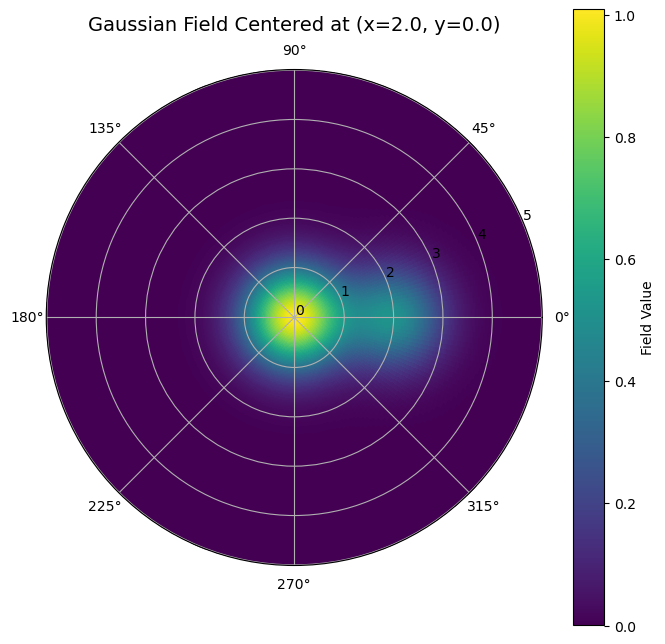

In [10]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
c = ax.pcolormesh(TH, R, field_values_offcenter+field_values, shading='auto', cmap='viridis')
fig.colorbar(c, ax=ax, label='Field Value')
ax.set_title(f"Gaussian Field Centered at (x={gaus_params_offcenter['XC']}, y={gaus_params_offcenter['YC']})", va='bottom', fontsize=14)
plt.show()